In [21]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the training dataset
df = pd.read_csv(
    "/kaggle/input/datasets/anmolkumar/house-price-prediction-challenge/train.csv"
)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

display(df.head())

/kaggle/input/datasets/anmolkumar/house-price-prediction-challenge/sample_submission.csv
/kaggle/input/datasets/anmolkumar/house-price-prediction-challenge/train.csv
/kaggle/input/datasets/anmolkumar/house-price-prediction-challenge/test.csv
Dataset loaded successfully!
Dataset shape: (29451, 12)


,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_NO.,BHK_OR_RK,SQUARE_FT,READY_TO_MOVE,RESALE,ADDRESS,LONGITUDE,LATITUDE,TARGET(PRICE_IN_LACS)
0,Owner,0,0,2,BHK,1300.236407,1,1,"Ksfc Layout,Bangalore",12.969910,77.597960,55.0
1,Dealer,0,0,2,BHK,1275.000000,1,1,"Vishweshwara Nagar,Mysore",12.274538,76.644605,51.0
2,Owner,0,0,2,BHK,933.159722,1,1,"Jigani,Bangalore",12.778033,77.632191,43.0
3,Owner,0,1,2,BHK,929.921143,1,1,"Sector-1 Vaishali,Ghaziabad",28.642300,77.344500,62.5
4,Dealer,1,0,2,BHK,999.009247,0,1,"New Town,Kolkata",22.592200,88.484911,60.5


In [22]:
print("Column Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Column Names:
['POSTED_BY', 'UNDER_CONSTRUCTION', 'RERA', 'BHK_NO.', 'BHK_OR_RK', 'SQUARE_FT', 'READY_TO_MOVE', 'RESALE', 'ADDRESS', 'LONGITUDE', 'LATITUDE', 'TARGET(PRICE_IN_LACS)']

Data Types:
POSTED_BY                 object
UNDER_CONSTRUCTION         int64
RERA                       int64
BHK_NO.                    int64
BHK_OR_RK                 object
SQUARE_FT                float64
READY_TO_MOVE              int64
RESALE                     int64
ADDRESS                   object
LONGITUDE                float64
LATITUDE                 float64
TARGET(PRICE_IN_LACS)    float64
dtype: object

Missing Values:
POSTED_BY                0
UNDER_CONSTRUCTION       0
RERA                     0
BHK_NO.                  0
BHK_OR_RK                0
SQUARE_FT                0
READY_TO_MOVE            0
RESALE                   0
ADDRESS                  0
LONGITUDE                0
LATITUDE                 0
TARGET(PRICE_IN_LACS)    0
dtype: int64

Duplicate Rows:
401


In [23]:
print("Numerical Summary:")
display(df.describe())

Numerical Summary:


,UNDER_CONSTRUCTION,RERA,BHK_NO.,SQUARE_FT,READY_TO_MOVE,RESALE,LONGITUDE,LATITUDE,TARGET(PRICE_IN_LACS)
count,29451.000000,29451.000000,29451.000000,2.945100e+04,29451.000000,29451.000000,29451.000000,29451.000000,29451.000000
mean,0.179756,0.317918,2.392279,1.980217e+04,0.820244,0.929578,21.300255,76.837695,142.898746
std,0.383991,0.465675,0.879091,1.901335e+06,0.383991,0.255861,6.205306,10.557747,656.880713
min,0.000000,0.000000,1.000000,3.000000e+00,0.000000,0.000000,-37.713008,-121.761248,0.250000
25%,0.000000,0.000000,2.000000,9.000211e+02,1.000000,1.000000,18.452663,73.798100,38.000000
50%,0.000000,0.000000,2.000000,1.175057e+03,1.000000,1.000000,20.750000,77.324137,62.000000
75%,0.000000,1.000000,3.000000,1.550688e+03,1.000000,1.000000,26.900926,77.828740,100.000000
max,1.000000,1.000000,20.000000,2.545455e+08,1.000000,1.000000,59.912884,152.962676,30000.000000


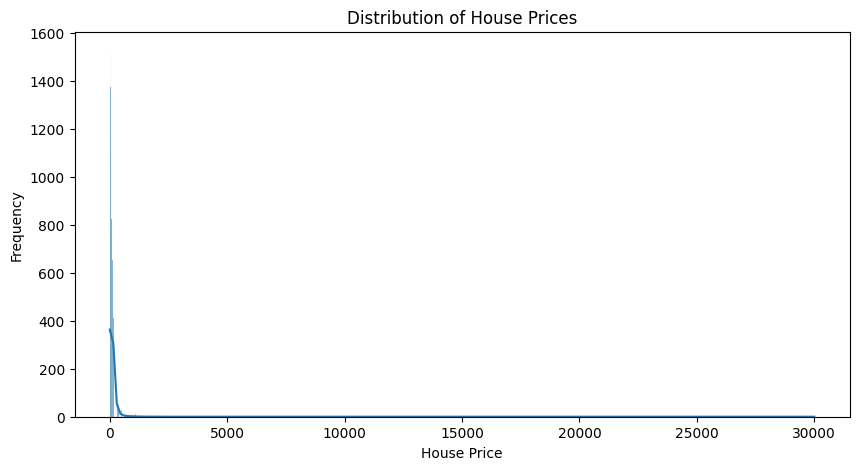

In [24]:
plt.figure(figsize=(10, 5))
sns.histplot(df[df.columns[-1]], kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("House Price")
plt.ylabel("Frequency")
plt.show()

## 2. Duplicate Removal

The dataset contains duplicate records that may cause repeated observations to influence the regression model.

A total of 401 duplicate rows were identified. These duplicate records are removed before model training to improve data quality and prevent repeated observations from affecting the results.

In [25]:
# Check duplicate count before removal
duplicates_before = df.duplicated().sum()

# Remove duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

# Check duplicate count after removal
duplicates_after = df.duplicated().sum()

print("Duplicates before cleaning:", duplicates_before)
print("Duplicates after cleaning:", duplicates_after)
print("Dataset shape after removing duplicates:", df.shape)

Duplicates before cleaning: 401
Duplicates after cleaning: 0
Dataset shape after removing duplicates: (29050, 12)


## 3. Feature Selection

The target variable for this project is `TARGET(PRICE_IN_LACS)`, which represents the house price in lakh rupees.

The following features are selected as potential predictors:

- `UNDER_CONSTRUCTION` – indicates whether the property is still under construction.
- `RERA` – indicates whether the property is RERA registered.
- `BHK_NO.` – number of bedrooms/hall/kitchen units.
- `BHK_OR_RK` – indicates whether the property is a BHK or RK unit.
- `SQUARE_FT` – property size and an important predictor of price.
- `READY_TO_MOVE` – indicates whether the property is ready for occupation.
- `RESALE` – indicates whether the property is being resold.
- `LONGITUDE` and `LATITUDE` – provide geographical information that can influence property prices.
- `POSTED_BY` – identifies the type of seller.

The `ADDRESS` column is excluded because it contains high-cardinality text values. Directly using individual addresses would create a very large number of categorical variables and would not be appropriate for this simple linear regression model.

In [26]:
# Define target
target = "TARGET(PRICE_IN_LACS)"

# Select features
features = [
    "POSTED_BY",
    "UNDER_CONSTRUCTION",
    "RERA",
    "BHK_NO.",
    "BHK_OR_RK",
    "SQUARE_FT",
    "READY_TO_MOVE",
    "RESALE",
    "LONGITUDE",
    "LATITUDE"
]

X = df[features].copy()
y = df[target].copy()

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

Features:
['POSTED_BY', 'UNDER_CONSTRUCTION', 'RERA', 'BHK_NO.', 'BHK_OR_RK', 'SQUARE_FT', 'READY_TO_MOVE', 'RESALE', 'LONGITUDE', 'LATITUDE']

Target:
TARGET(PRICE_IN_LACS)

Feature shape: (29050, 10)
Target shape: (29050,)


## 4. Handling Categorical Features

The dataset contains categorical variables such as `POSTED_BY` and `BHK_OR_RK`.

Since Linear Regression requires numerical input, these categorical variables are converted into numerical features using One-Hot Encoding.

The `ADDRESS` column is excluded because it contains high-cardinality location text and would create too many individual categories.

In [27]:
# One-hot encode categorical variables
X_encoded = pd.get_dummies(
    X,
    columns=["POSTED_BY", "BHK_OR_RK"],
    drop_first=True,
    dtype=int
)

print("Shape after encoding:", X_encoded.shape)
print("\nEncoded columns:")
print(X_encoded.columns.tolist())

Shape after encoding: (29050, 11)

Encoded columns:
['UNDER_CONSTRUCTION', 'RERA', 'BHK_NO.', 'SQUARE_FT', 'READY_TO_MOVE', 'RESALE', 'LONGITUDE', 'LATITUDE', 'POSTED_BY_Dealer', 'POSTED_BY_Owner', 'BHK_OR_RK_RK']


## 5. Correlation Analysis

Correlation analysis is used to understand the relationship between numerical features and house prices.

A heatmap is created to identify features that may have stronger relationships with the target variable. This helps explain which variables are potentially useful predictors before training the regression model.

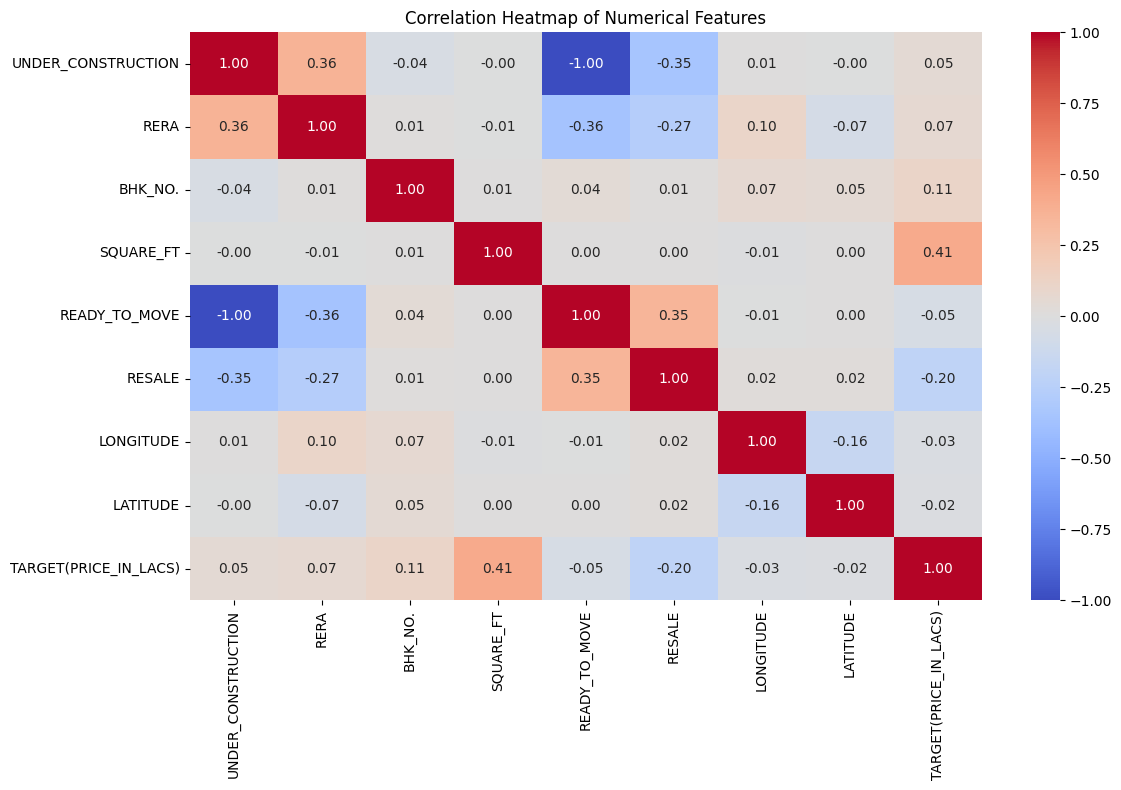

In [28]:
plt.figure(figsize=(12, 8))

correlation = df[
    [
        "UNDER_CONSTRUCTION",
        "RERA",
        "BHK_NO.",
        "SQUARE_FT",
        "READY_TO_MOVE",
        "RESALE",
        "LONGITUDE",
        "LATITUDE",
        "TARGET(PRICE_IN_LACS)"
    ]
].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

## 6. Train-Test Split

The cleaned and encoded dataset is divided into training and testing sets.

80% of the data is used to train the model, while 20% is reserved for testing. A fixed random state is used to make the results reproducible.

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Training features:", X_train.shape[1])

Training samples: 23240
Testing samples: 5810
Training features: 11


## 7. Linear Regression Model

Linear Regression is used to predict house prices based on the selected property features.

The model estimates the relationship between the independent variables and the target house price. The trained model is then used to predict prices for the unseen test dataset.

In [30]:
from sklearn.linear_model import LinearRegression

# Create and train the model
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

# Make predictions
y_pred = linear_model.predict(X_test)

print("Linear Regression model trained successfully!")
print("Number of predictions:", len(y_pred))

Linear Regression model trained successfully!
Number of predictions: 5810


## 8. Model Evaluation

The Linear Regression model is evaluated using four standard regression metrics:

- **MAE (Mean Absolute Error):** average absolute difference between actual and predicted prices.
- **MSE (Mean Squared Error):** average squared prediction error.
- **RMSE (Root Mean Squared Error):** square root of MSE and expressed in the same unit as the target.
- **R² Score:** indicates how much variation in house prices is explained by the model. Higher values generally indicate better performance.

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Performance")
print("-" * 35)
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

Linear Regression Performance
-----------------------------------
MAE  : 139.2218
MSE  : 364451.6602
RMSE : 603.6983
R²   : 0.3344


## 9. Actual vs Predicted Prices

The actual versus predicted scatter plot compares the prices observed in the test set with the prices predicted by the Linear Regression model.

A strong model would have predictions concentrated around the diagonal relationship between actual and predicted values.

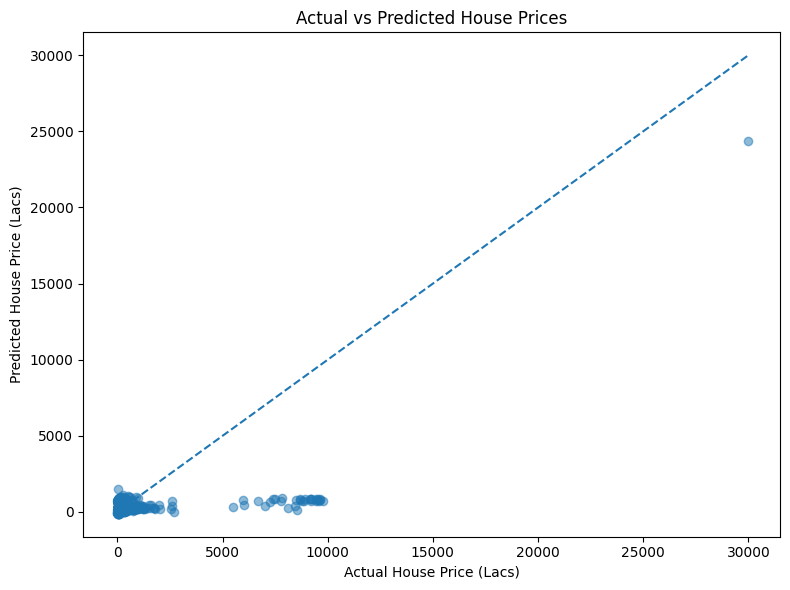

In [32]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.5)

# Reference line
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual House Price (Lacs)")
plt.ylabel("Predicted House Price (Lacs)")
plt.title("Actual vs Predicted House Prices")
plt.tight_layout()
plt.show()

## 10. Residual Analysis

Residuals represent the difference between the actual and predicted house prices.

A residual plot helps identify systematic errors in the model. Ideally, residuals should be distributed randomly around zero without a clear pattern.

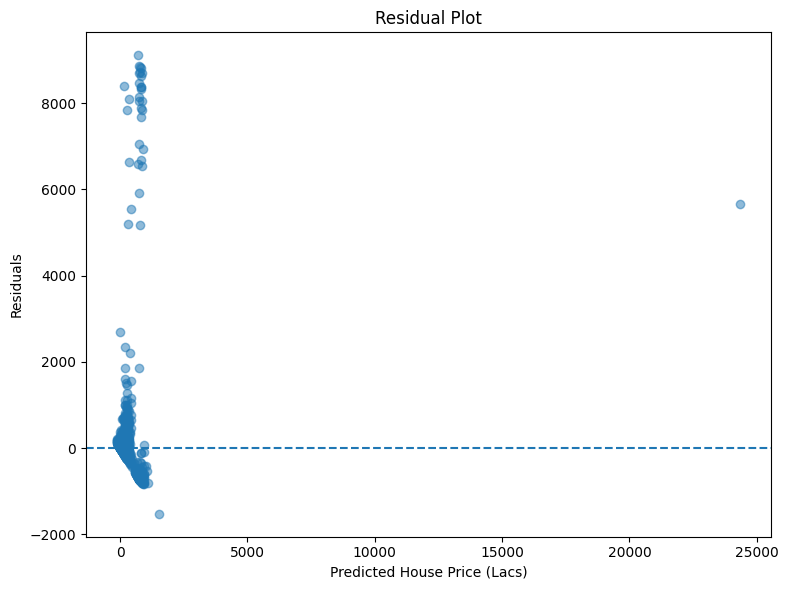

In [33]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))

plt.scatter(y_pred, residuals, alpha=0.5)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted House Price (Lacs)")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.tight_layout()
plt.show()

## 11. Feature Coefficient Analysis

Linear Regression coefficients indicate how each feature contributes to the predicted house price while other features are held constant.

Positive coefficients indicate a positive association with predicted price, while negative coefficients indicate a negative association.

In [34]:
coefficients = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Coefficient": linear_model.coef_
})

coefficients["Absolute_Coefficient"] = coefficients["Coefficient"].abs()

coefficients = coefficients.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

display(coefficients)

,Feature,Coefficient,Absolute_Coefficient
5,RESALE,-640.481616,640.481616
8,POSTED_BY_Dealer,501.381360,501.381360
9,POSTED_BY_Owner,432.597962,432.597962
2,BHK_NO.,82.550464,82.550464
0,UNDER_CONSTRUCTION,-17.177409,17.177409
4,READY_TO_MOVE,17.177409,17.177409
1,RERA,13.266663,13.266663
10,BHK_OR_RK_RK,-13.213256,13.213256
6,LONGITUDE,-4.423464,4.423464
7,LATITUDE,-1.401893,1.401893


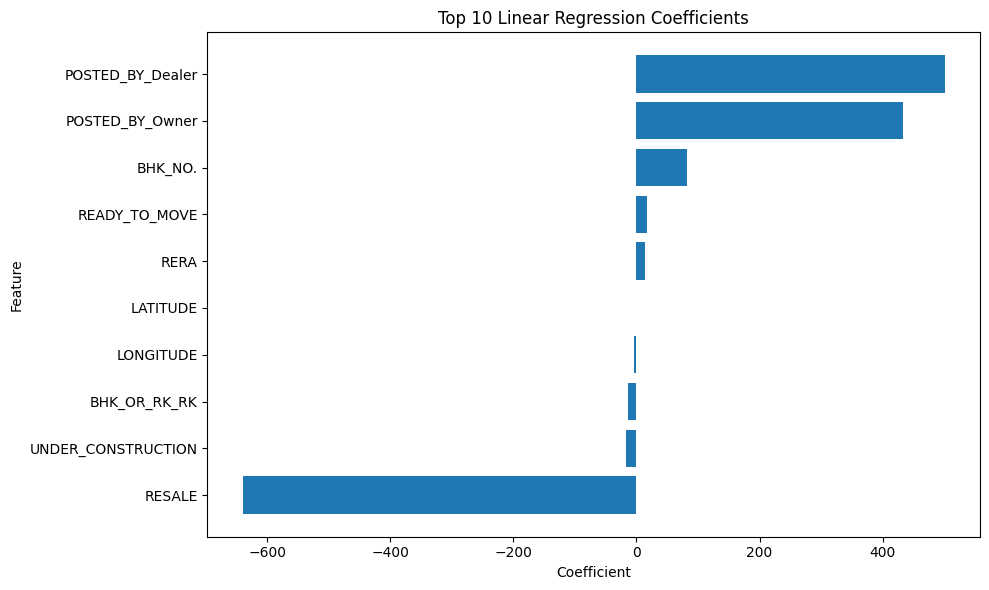

In [35]:
top_coefficients = coefficients.head(10).sort_values("Coefficient")

plt.figure(figsize=(10, 6))

plt.barh(
    top_coefficients["Feature"],
    top_coefficients["Coefficient"]
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Top 10 Linear Regression Coefficients")
plt.tight_layout()
plt.show()

## 12. Ridge Regression Comparison

Ridge Regression is a regularized version of Linear Regression that adds a penalty to large coefficients.

It can help reduce overfitting and improve model stability when predictors contain correlated or high-dimensional features.

The Ridge model is compared with the original Linear Regression model using MAE, MSE, RMSE, and R².

In [36]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

# Standardize the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Ridge Regression
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_scaled, y_train)

# Make predictions
ridge_pred = ridge_model.predict(X_test_scaled)

# Evaluate Ridge Regression
ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge Regression Performance")
print("-" * 35)
print(f"MAE  : {ridge_mae:.4f}")
print(f"MSE  : {ridge_mse:.4f}")
print(f"RMSE : {ridge_rmse:.4f}")
print(f"R²   : {ridge_r2:.4f}")

Ridge Regression Performance
-----------------------------------
MAE  : 139.2224
MSE  : 364456.2698
RMSE : 603.7021
R²   : 0.3344


In [37]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression"
    ],
    "MAE": [
        mae,
        ridge_mae
    ],
    "MSE": [
        mse,
        ridge_mse
    ],
    "RMSE": [
        rmse,
        ridge_rmse
    ],
    "R2": [
        r2,
        ridge_r2
    ]
})

display(comparison)

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,139.221789,364451.660244,603.698319,0.334416
1,Ridge Regression,139.222379,364456.269794,603.702137,0.334408


## 13. Model Performance Comparison

Linear Regression and Ridge Regression were compared using MAE, MSE, RMSE, and R².

Linear Regression achieved slightly lower MAE, MSE, and RMSE and a marginally higher R² score than Ridge Regression. Therefore, Linear Regression is selected as the final model.

However, the difference between the two models is very small, indicating that Ridge regularization does not substantially improve performance for this dataset.

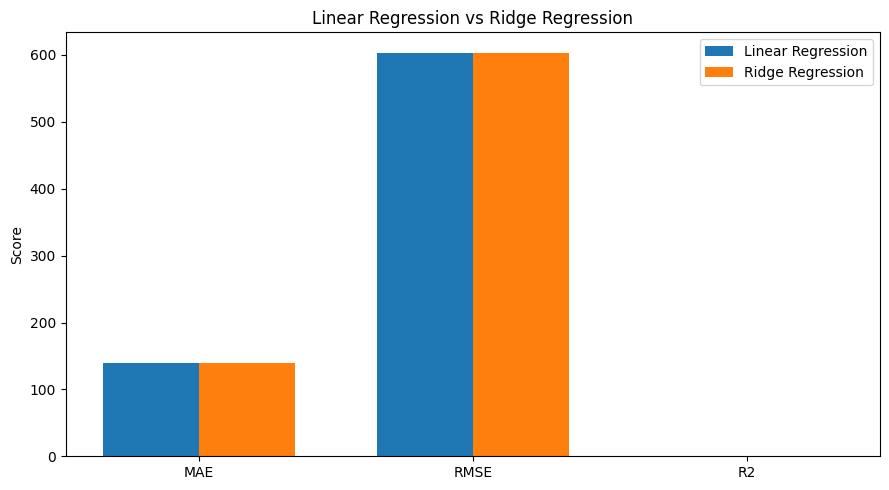

In [38]:
# Visual comparison of model performance

metrics = ["MAE", "RMSE", "R2"]

linear_values = [mae, rmse, r2]
ridge_values = [ridge_mae, ridge_rmse, ridge_r2]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(x - width/2, linear_values, width, label="Linear Regression")
plt.bar(x + width/2, ridge_values, width, label="Ridge Regression")

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Linear Regression vs Ridge Regression")
plt.legend()
plt.tight_layout()
plt.show()

## 14. Conclusion

A Linear Regression model was developed to predict house prices using property characteristics such as BHK count, square footage, RERA status, resale status, seller type, and geographical coordinates.

After removing 401 duplicate records, the dataset contained 29,050 observations. Categorical variables were converted using One-Hot Encoding, and the data was divided into training and testing sets using an 80:20 split.

The Linear Regression model achieved:

- MAE: 139.2218
- MSE: 364451.6602
- RMSE: 603.6983
- R²: 0.3344

Ridge Regression was also tested as a regularized alternative. Its performance was almost identical to Linear Regression, with a slightly lower R² of 0.3344. Therefore, Linear Regression was selected as the final model.

The R² score indicates that the model explains approximately 33.44% of the variation in house prices. The remaining variation may be influenced by additional factors such as specific location, neighborhood characteristics, property amenities, building quality, and other market conditions that are not fully represented by the available features.

This project demonstrates how machine learning can be applied to real-estate price prediction and can support property valuation, market analysis, and decision-making.